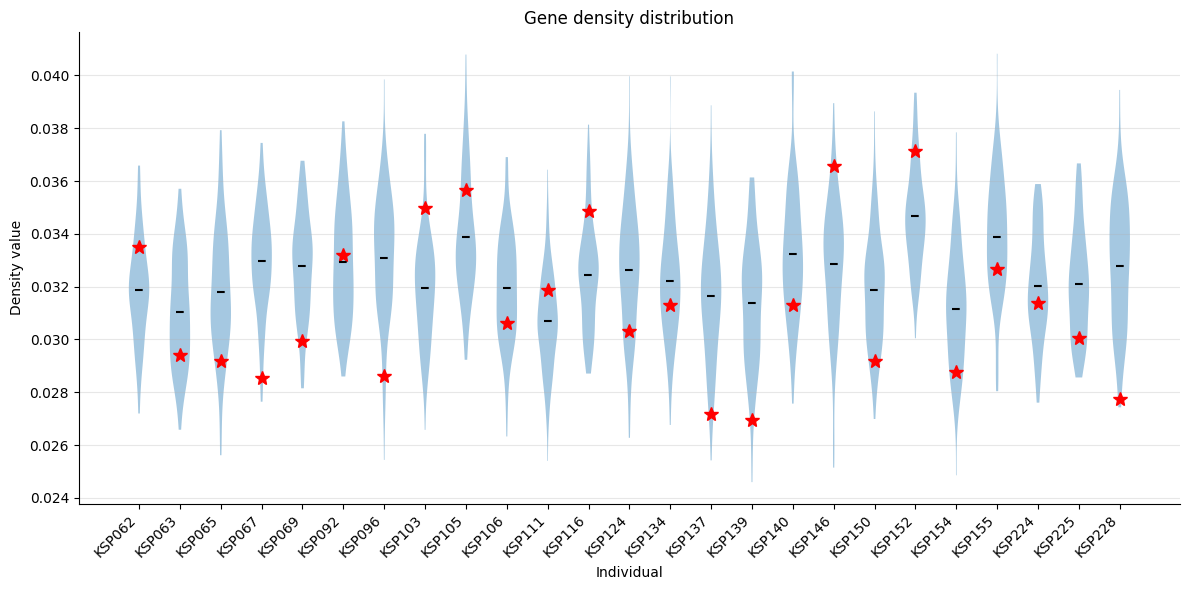

In [14]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

file_list = [
    "KSP062_variant_density.csv",
    "KSP063_variant_density.csv",
    "KSP065_variant_density.csv",
    "KSP067_variant_density.csv",
    "KSP069_variant_density.csv",
    "KSP092_variant_density.csv",
    "KSP096_variant_density.csv",
    "KSP103_variant_density.csv",
    "KSP105_variant_density.csv",
    "KSP106_variant_density.csv",
    "KSP111_variant_density.csv",
    "KSP116_variant_density.csv",
    "KSP124_variant_density.csv",
    "KSP134_variant_density.csv",
    "KSP137_variant_density.csv",
    "KSP139_variant_density.csv",
    "KSP140_variant_density.csv",
    "KSP146_variant_density.csv",
    "KSP150_variant_density.csv",
    "KSP152_variant_density.csv",
    "KSP154_variant_density.csv",
    "KSP155_variant_density.csv",
    "KSP224_variant_density.csv",
    "KSP225_variant_density.csv",
    "KSP228_variant_density.csv"
]

def extract_data_from_file(filename):
    df = pd.read_csv(filename)
    
    # Find the first row where 'RealRegion' is empty (NaN or "")
    condition = df["RealRegion"].isna() | (df["RealRegion"] == "")
    matching_indices = df[condition].index.tolist()
    if not matching_indices:
        return None, None
    
    # Use the row right after the empty one
    empty_row_index = matching_indices[0]
    needed_row_index = empty_row_index + 1
    
    # Check if the needed row is in range
    if needed_row_index >= len(df):
        return None, None
    
    # Extract columns "RandomDensity_1" through "RandomDensity_100"
    random_cols = [f"RandomDensity_{i}" for i in range(1, 101)]
    random_values = df.loc[needed_row_index, random_cols].astype(float).to_numpy()
    
    # Extract the empirical value from "RealDensity"
    empirical_value = float(df.loc[needed_row_index, "RealDensity"])
    
    return random_values, empirical_value

all_random_values = []
all_empirical_values = []
all_labels = []  # Will store the label (e.g. "KSP062") for each file

for fpath in file_list:
    rv, ev = extract_data_from_file(fpath)
    if rv is not None and ev is not None:
        # Append data
        all_random_values.append(rv)
        all_empirical_values.append(ev)
        
        # Derive label from file name
        # 1) Get the base name without any directories
        base_name = os.path.basename(fpath)  # e.g. "KSP062_variant_density.csv"
        # 2) Remove the file extension
        name_no_ext = os.path.splitext(base_name)[0]  # e.g. "KSP062_variant_density"
        # 3) Remove the "_variant_density" part
        label = name_no_ext.replace("_variant_density", "")  # e.g. "KSP062"
        
        all_labels.append(label)

fig, ax = plt.subplots(figsize=(12, 6))
positions = np.arange(1, len(all_random_values) + 1)

# Violin plots
parts = ax.violinplot(
    all_random_values,
    positions=positions,
    showmeans=False,
    showextrema=False
)

# Make violins somewhat transparent
for pc in parts['bodies']:
    pc.set_alpha(0.4)

# Plot star for each empirical value (dark yellow)
for i, emp_val in enumerate(all_empirical_values, start=1):
    ax.plot(i, emp_val, marker="*", markersize=10, color="red")

# Dashed horizontal line for the mean of each violin
for i, rv in enumerate(all_random_values, start=1):
    random_mean = np.mean(rv)
    ax.hlines(random_mean, i - 0.1, i + 0.1, linestyles="dashed", color="black")

# Aesthetics
ax.set_title("Gene density distribution")
ax.set_xlabel("Individual")
ax.set_ylabel("Density value")

# Use the extracted file-based labels
ax.set_xticks(positions)
ax.set_xticklabels(all_labels, rotation=45, ha="right")

# Hide top/right spines, add subtle grid
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.grid(True, axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig("San_gene_density_distribution.png", dpi=300)
plt.show()


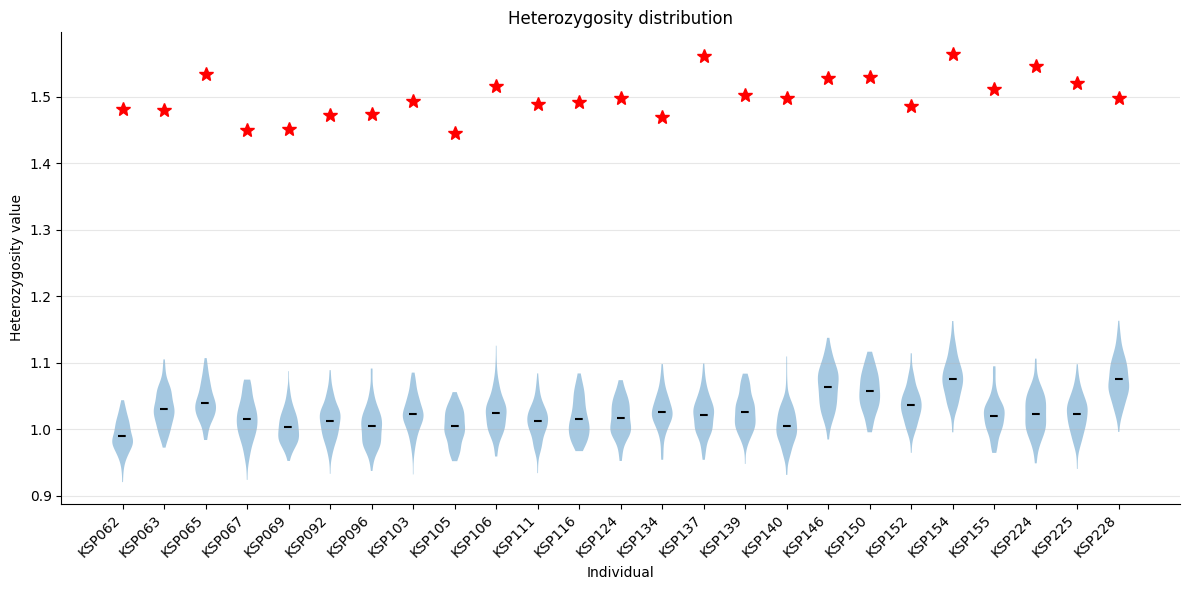

In [25]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

file_list = [
    "KSP062_heterozygosity_reset.csv",
    "KSP063_heterozygosity_reset.csv",
    "KSP065_heterozygosity_reset.csv",
    "KSP067_heterozygosity_reset.csv",
    "KSP069_heterozygosity_reset.csv",
    "KSP092_heterozygosity_reset.csv",
    "KSP096_heterozygosity_reset.csv",
    "KSP103_heterozygosity_reset.csv",
    "KSP105_heterozygosity_reset.csv",
    "KSP106_heterozygosity_reset.csv",
    "KSP111_heterozygosity_reset.csv",
    "KSP116_heterozygosity_reset.csv",
    "KSP124_heterozygosity_reset.csv",
    "KSP134_heterozygosity_reset.csv",
    "KSP137_heterozygosity_reset.csv",
    "KSP139_heterozygosity_reset.csv",
    "KSP140_heterozygosity_reset.csv",
    "KSP146_heterozygosity_reset.csv",
    "KSP150_heterozygosity_reset.csv",
    "KSP152_heterozygosity_reset.csv",
    "KSP154_heterozygosity_reset.csv",
    "KSP155_heterozygosity_reset.csv",
    "KSP224_heterozygosity_reset.csv",
    "KSP225_heterozygosity_reset.csv",
    "KSP228_heterozygosity_reset.csv"
]

def extract_data_from_file(filename):
    df = pd.read_csv(filename, low_memory=False)
    
    # Find the first row where 'RealRegion' is empty (NaN or "")
    condition = df["Real Region"].isna() | (df["Real Region"] == "")
    matching_indices = df[condition].index.tolist()
    if not matching_indices:
        return None, None
    
    # Use the row right after the empty one
    empty_row_index = matching_indices[0]
    needed_row_index = empty_row_index + 2
    
    # Check if the needed row is in range
    if needed_row_index >= len(df):
        return None, None
    
    # Extract columns "RandomDensity_1" through "RandomDensity_100"
    random_cols = [f"Random_Het_{i}" for i in range(1, 101)]
    random_values = df.loc[needed_row_index, random_cols].astype(float).to_numpy()
    
    # Extract the empirical value from "RealDensity"
    empirical_value = float(df.loc[needed_row_index, "Real Heterozygosity"])
    
    return random_values, empirical_value

all_random_values = []
all_empirical_values = []
all_labels = []  # Will store the label (e.g. "KSP062") for each file

for fpath in file_list:
    rv, ev = extract_data_from_file(fpath)
    if rv is not None and ev is not None:
        # Append data
        all_random_values.append(rv)
        all_empirical_values.append(ev)
        
        # Derive label from file name
        # 1) Get the base name without any directories
        base_name = os.path.basename(fpath)  # e.g. "KSP062_variant_density.csv"
        # 2) Remove the file extension
        name_no_ext = os.path.splitext(base_name)[0]  # e.g. "KSP062_variant_density"
        # 3) Remove the "_variant_density" part
        label = name_no_ext.replace("_heterozygosity_reset", "")  # e.g. "KSP062"
        
        all_labels.append(label)

fig, ax = plt.subplots(figsize=(12, 6))
positions = np.arange(1, len(all_random_values) + 1)

# Violin plots
parts = ax.violinplot(
    all_random_values,
    positions=positions,
    showmeans=False,
    showextrema=False
)

# Make violins somewhat transparent
for pc in parts['bodies']:
    pc.set_alpha(0.4)

# Plot star for each empirical value (dark yellow)
for i, emp_val in enumerate(all_empirical_values, start=1):
    ax.plot(i, emp_val, marker="*", markersize=10, color="red")

# Dashed horizontal line for the mean of each violin
for i, rv in enumerate(all_random_values, start=1):
    random_mean = np.mean(rv)
    ax.hlines(random_mean, i - 0.1, i + 0.1, linestyles="dashed", color="black")

# Aesthetics
ax.set_title("Heterozygosity distribution")
ax.set_xlabel("Individual")
ax.set_ylabel("Heterozygosity value")

# Use the extracted file-based labels
ax.set_xticks(positions)
ax.set_xticklabels(all_labels, rotation=45, ha="right")

# Hide top/right spines, add subtle grid
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.grid(True, axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig("San_heterozygosity_distribution.png", dpi=300)
plt.show()
